In [199]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

import importlib
# importlib.reload(sys.modules['src'])
importlib.reload(sys.modules['utils.bosonization'])
importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
print(f"TeNPy version: {tenpy.__version__}")

TeNPy version: 1.1.0


In [2]:
model_params = dict(
        t=1, U=2, Vpp=0.1, Vpm=2, mu=0.0,
        bc_MPS="infinite",
        L=2,
    )
model = HubbardSpinDepV(model_params)
model.lat.N_sites

2

In [31]:
print("Vpm_crit = ", ret_Vpm_crit(1, 0.1, 0.8))
tstart = time.perf_counter()
E, psi, model = run_idmrg(t=1, U=0.1, Vpp=0.8, Vpm=5.0, chi_max=100, n_sweeps=1000, max_err=1e-4)
tstop = time.perf_counter()
print("Elapsed Wall clock time in seconds : ", tstop - tstart)

INFO:tenpy.tools.params:HubbardSpinDepV: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'L'=2
INFO:tenpy.tools.params:HubbardSpinDepV: reading 't'=1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'U'=0.1
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpp'=0.8
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'Vpm'=5.0
INFO:tenpy.tools.params:HubbardSpinDepV: reading 'mu'=0.0
/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)
INFO:tenpy.tools.params:TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<3 options>, 'trunc_params

Vpm_crit =  3.891592653589793
  t=1  U=0.1  V^{++}=0.8  V^{+-}=5.0
  ΔV = V^{+-} - V^{++} = 4.200  (>0 drives FM)


INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'chi_list'={0: 50, 21: 75, 51: 100}
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.tools.params:trunc_params: reading 'chi_max'=100
INFO:tenpy.tools.params:trunc_params: reading 'svd_min'=1e-11
INFO:tenpy.tools.params:trunc_params: reading 'trunc_cut'=1e-08
INFO:tenpy.tools.params:TwoSiteDMRGEngine: subconfig 'mixer_params'=Config(<3 options>, 'mixer_params')
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'mixer'='DensityMatrixMixer'
INFO:tenpy.algorithms.mps_common:activate DensityMatrixMixer with initial amplitude 1e-05
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'max_sweeps'=1000
INFO:tenpy.algorithms.dmrg:Running sweep with optimization
INFO:tenpy.algorithms.mps_common:Setting chi_max=50
INFO:tenpy.algorithms.mps_common:activate DensityMatrixMixer with initial amplitude 1e-05
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'update_env'=10
INFO:tenpy.algorithms.mps_common:start environment_sweep
IN


Ground state energy per site: E/N = -0.5582957844

Unit-cell observables:
  site        <Sz>       <Nup>       <Ndn>      <Ntot>
  --------------------------------------------------
     0   -0.208653    0.000000    0.417306    0.417306
     1   -0.208653    0.000000    0.417306    0.417306

  Mean <Sz>     = -0.208653
  Mean filling  = 0.417306  (should be 1.0 at half filling)

  Spin susceptibility (q=0 sum): χ ≈ 0.1202

  Spin structure factor S(q) [from unit-cell correlations]:
Elapsed Wall clock time in seconds :  2780.7232362320647


In [32]:
filename = "testTenPy.h5"
io.save_mps_with_metadata(filename, mps=psi)
loaded, _ = io.load_mps_with_metadata(filename)
loaded.overlap(psi)

/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:4234: UserWarning: The returned overlap between two iMPS is **not** just <phi|psi>, as you might assume naively, but here defined to return the dominant eigenvalue eta of the (mixed) TransferMatrix. The former is lim_{N -> infty} eta^N and vanishes in the thermodynamic limit! See the warning in the docs of tenpy.networks.mps.
  warnings.warn(


np.complex128(0.9999999999999895+0j)

In [95]:
Kc, Ks = compute_Luttinger_parameter(t=1, U=0.1, Vpp=0.8, Vpm=5.0)
print(Kc, Ks)
print(0.25 * (Kc + 1./Kc + np.abs(Ks) + np.abs(1./Ks)))

(0.5910940999670402+0j) -1.6835469742492202j
(1.1401007760402129+0j)


In [33]:
psi.correlation_length()

/tmp/ipykernel_317910/2963323589.py:1: DeprecationWarning: The method `correlation_length` is deprecated. Use `correlation_length2` instead. Note the different units of the output for higher-dimensional lattices!
  psi.correlation_length()


np.float64(339.9725162402423)

In [85]:
corrfn = psi.correlation_function("Sz", "Sz", [0], 200)[0]
magz = psi.expectation_value("Sz")[0]
conn_corr = np.abs(corrfn - magz**2)
electron_corr_fn = psi.correlation_function("Cdd", "Cd", [0], 200)[0]

/tmp/ipykernel_317910/2359482760.py:2: RuntimeWarning: divide by zero encountered in power
  plt.loglog(0.024 * np.arange(200,dtype=float)**(-1.65), label=r'$x^{-1.65}$')


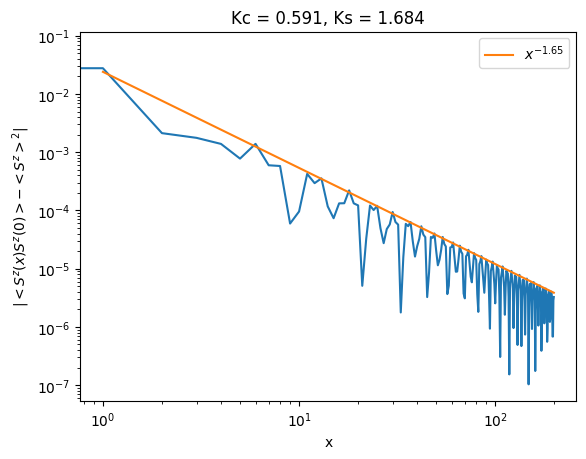

In [121]:
plt.loglog(conn_corr)
plt.loglog(0.024 * np.arange(200,dtype=float)**(-1.65), label=r'$x^{-1.65}$')
plt.xlabel('x')
plt.ylabel(r'$|<S^z(x)S^z(0)> - <S^z>^2 |$')
plt.title(f'Kc = {np.abs(Kc):.3f}, Ks = {np.abs(Ks):.3f}')
plt.legend()
# plt.savefig('../../pngfigs/iDMRG/FMSzcorr.png')

/tmp/ipykernel_317910/132551434.py:2: RuntimeWarning: divide by zero encountered in power
  plt.loglog(0.275 * np.arange(200, dtype=float)**(-1.0), label=r'$x^{-1}$')


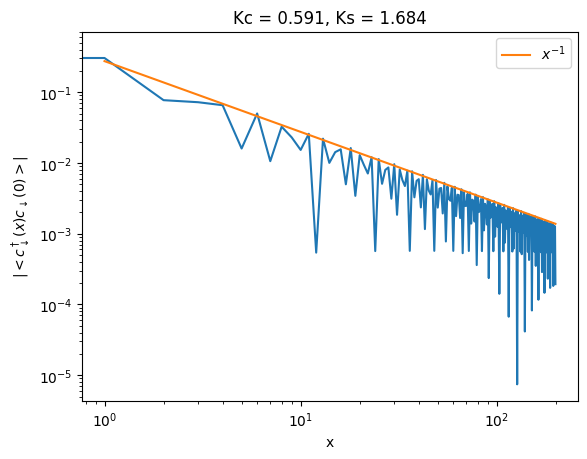

In [117]:
plt.loglog(np.abs(electron_corr_fn))
plt.loglog(0.275 * np.arange(200, dtype=float)**(-1.0), label=r'$x^{-1}$')
plt.xlabel('x')
plt.ylabel(r'$|<c^\dagger_\downarrow(x)c_\downarrow(0)> |$')
plt.title(f'Kc = {np.abs(Kc):.3f}, Ks = {np.abs(Ks):.3f}')
plt.legend()
# plt.savefig('../../pngfigs/iDMRG/FMfermcorr.png')

In [123]:
charge_corr_fn = psi.correlation_function("Ntot", "Ntot", [0], 200)[0]
avcharge = psi.expectation_value("Ntot")[0]
conn_charge_corr = charge_corr_fn - avcharge**2

/tmp/ipykernel_317910/2210184857.py:2: RuntimeWarning: divide by zero encountered in power
  plt.loglog(0.1 * np.arange(200,dtype=float)**(-1.65), label=r'$x^{-1.65}$')


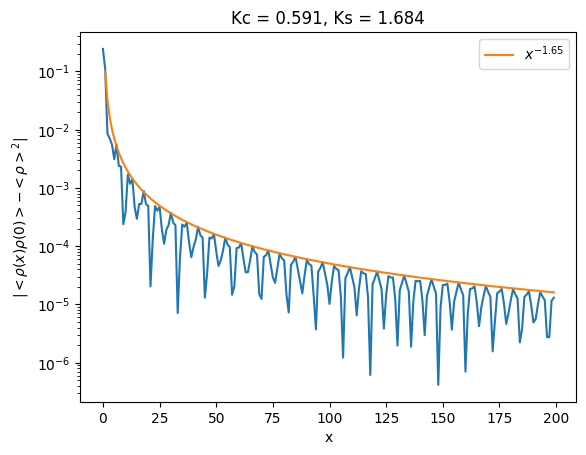

In [129]:
plt.loglog(np.abs(conn_charge_corr))
plt.loglog(0.1 * np.arange(200,dtype=float)**(-1.65), label=r'$x^{-1.65}$')
plt.xscale('linear')
plt.xlabel('x')
plt.ylabel(r'$|<\rho(x)\rho(0)> - <\rho>^2 |$')
plt.title(f'Kc = {np.abs(Kc):.3f}, Ks = {np.abs(Ks):.3f}')
plt.legend()
# plt.savefig('../../pngfigs/iDMRG/FMSrhocorr.png')

In [130]:
Sx_corr_fn = psi.correlation_function("Sx", "Sx", [0], 200)[0]

/tmp/ipykernel_317910/1877582520.py:2: RuntimeWarning: divide by zero encountered in power
  plt.loglog(5e-14 * np.arange(200,dtype=float)**(-1.65), label=r'$x^{-1.65}$')


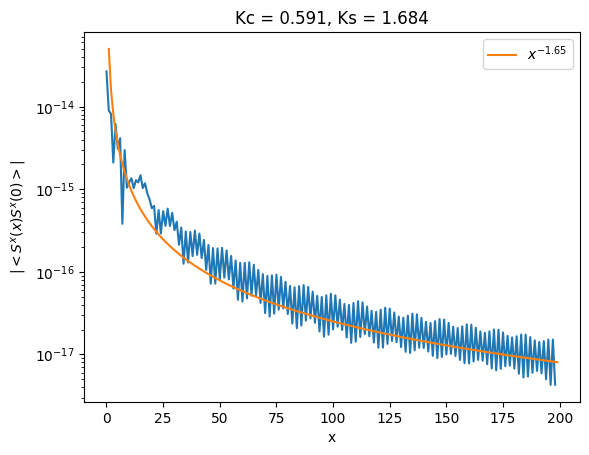

In [ ]:
plt.loglog(np.abs(Sx_corr_fn)[1:])
plt.loglog(5e-14 * np.arange(200,dtype=float)**(-1.65), label=r'$x^{-1.65}$')
plt.xscale('linear')
plt.xlabel('x')
plt.ylabel(r'$|<S^x(x)S^x(0)>|$')
plt.title(f'Kc = {np.abs(Kc):.3f}, Ks = {np.abs(Ks):.3f}')
plt.legend()
# plt.savefig('../../pngfigs/iDMRG/FMSxcorr.png')

In [183]:
import math

def interleaved_indices(n_items, n_tasks):
    """
    Returns indices ordered like

    n_tasks=2:
        0, mid, 1, mid+1, ...

    n_tasks=3:
        0, third, 2*third,
        1, third+1, 2*third+1, ...

    etc.
    """
    block_size = math.ceil(n_items / n_tasks)

    order = []
    for offset in range(block_size):
        for block in range(n_tasks):
            idx = block * block_size + offset
            if idx < n_items:
                order.append(idx)

    return order

In [206]:
t = 1.0
U = 0.1
Vpp = 0.8
dVlist = np.array([2.0, 2.6, 2.9, 3.0, 3.1, 3.2, 3.4])
Vpmlist = dVlist + Vpp

task_id = int(os.getenv("SLURM_ARRAY_TASK_ID", 2))
n_tasks = int(os.getenv("SLURM_ARRAY_TASK_COUNT", 3))

arr_for_task  = ret_arr_for_taskid(Vpmlist, n_tasks, task_id)


arr_for_task

# for x in my_Vpmlist:
#     f(x)

[np.float64(4.2), np.float64(3.7)]

In [209]:
d1 = {"a": 2, "b" : "stringsome"}
d2 = {"z1": 1, "z2" : 3}
d1["d2"] = d2
d1


{'a': 2, 'b': 'stringsome', 'd2': {'z1': 1, 'z2': 3}}

In [5]:
from tenpy.algorithms import dmrg as tenpy_dmrg
from tenpy.networks.mps import MPS
import sys 
sys.path.append('..')
from src.extendedHubbard import HubbardSpinDepV

t=1
U=0.1
Vpp=0.8
Vpm=3.2
model_params = dict(
    t=t, U=U, Vpp=Vpp, Vpm=Vpm, mu=0.0,
    bc_MPS="infinite",
    L=2,
)
model = HubbardSpinDepV(model_params)

# Half-filling, Sz=0 initial state
psi = MPS.from_product_state(model.lat.mps_sites(), ["up", "down"] , bc=model.lat.bc_MPS)
chi_max=20
n_sweeps=20
max_err=1e-5
chi_list = {0:chi_max//2, 21: int(3*chi_max/4), 51:chi_max}
dmrg_params = {
    "trunc_params": {
        "chi_max": chi_max,
        "svd_min": 1e-11,
        "trunc_cut": 1e-8,
    },
    "chi_list":chi_list,
    "mixer": "DensityMatrixMixer",
    "mixer_params": {
        "amplitude": 1e-5,
        "decay": 1.5,
        "disable_after": 30,
    },
    # "N_sweeps_check": 1,
    "min_sweeps": 4,
    "max_sweeps": n_sweeps,
    "update_env": 10,
    # "start_env": 10,
    'max_E_err': max_err, #precision in energy 
    'max_S_err': max_err, #precision in entropy
}

eng = tenpy_dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
E, psi = eng.run()   # E is energy per site for iDMRG


/scratch/ashankar/Spin1LongRangeOrder.jl/python/.venv/lib/python3.13/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


In [10]:
total_sweeps = eng.sweeps
converged = eng.is_converged()

if not converged and total_sweeps >= eng.options['max_sweeps']:
    print(f"Halted at maximum sweeps limit ({total_sweeps}) without fully converging.")

Halted at maximum sweeps limit (30) without fully converging.


In [12]:
res_data = eng.get_resume_data()

In [ ]:
eng.reset_stats(res_data)


IndexError: list index out of range